# Climate Insights & Conclusions

This notebook synthesizes findings from previous analysis to draw meaningful conclusions about rainfall patterns in India.

The focus is on:
- Climate variability
- Extreme events
- Regional risk
- Real-world implications

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive
drive.mount('/content/drive')
file_path = "/content/drive/MyDrive/cleaned_rainfall.csv"
df = pd.read_csv(file_path)

Mounted at /content/drive


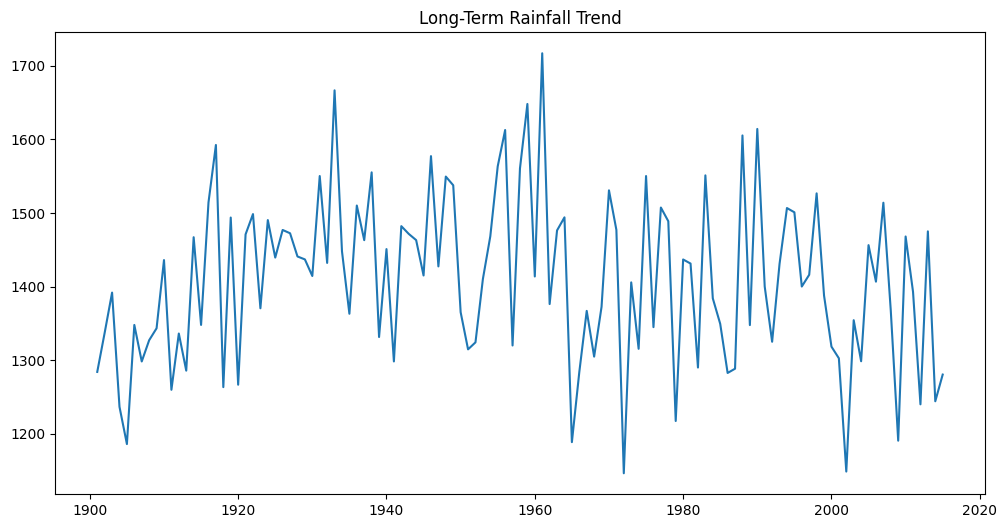

In [ ]:
yearly = df.groupby('year')['annual'].mean().reset_index()

plt.figure(figsize=(12,6))
plt.plot(yearly['year'], yearly['annual'])
plt.title("Long-Term Rainfall Trend")
plt.show()

### Climate Variability

Rainfall variability is a key indicator of climate stability.

Higher variability implies greater uncertainty, which can impact agriculture, water resources, and planning.

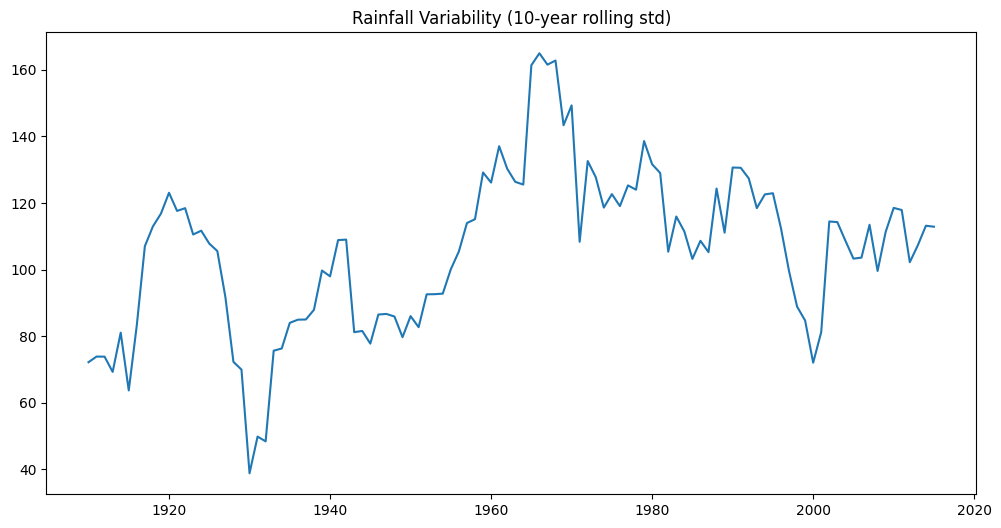

In [ ]:
yearly['rolling_std'] = yearly['annual'].rolling(10).std()

plt.figure(figsize=(12,6))
plt.plot(yearly['year'], yearly['rolling_std'])
plt.title("Rainfall Variability (10-year rolling std)")
plt.show()

### Extreme Rainfall Events

Extreme rainfall events are identified and analyzed over time.

An increase in such events may indicate growing climate instability.

In [ ]:
threshold = df['annual'].quantile(0.9)
extreme = df[df['annual'] > threshold]

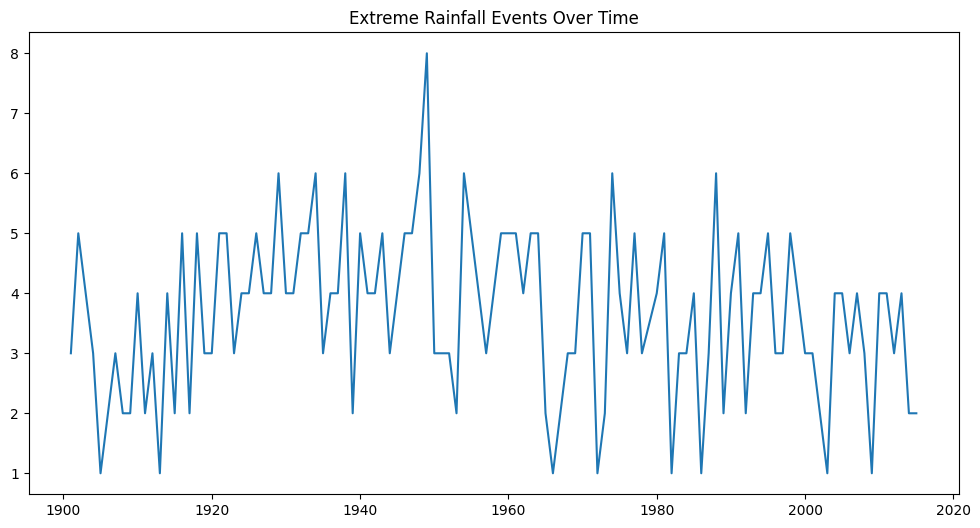

In [ ]:
extreme_years = extreme.groupby('year').size()

plt.figure(figsize=(12,6))
plt.plot(extreme_years.index, extreme_years.values)
plt.title("Extreme Rainfall Events Over Time")
plt.show()

### Model-Based Insight

The machine learning model reveals a strong temporal relationship in rainfall patterns.

However, prediction errors highlight the complexity of climate systems.

In [ ]:
risk = df.groupby('region')['annual'].std().sort_values(ascending=False)
risk.head(10)

,annual
region,
ARUNACHAL PRADESH,1183.490399
ANDAMAN & NICOBAR ISLANDS,573.301222
COASTAL KARNATAKA,525.726583
KONKAN & GOA,485.095477
NAGA MANI MIZO TRIPURA,431.734909
KERALA,422.112193
SUB HIMALAYAN WEST BENGAL & SIKKIM,337.854553
ASSAM & MEGHALAYA,310.195411
LAKSHADWEEP,291.995164


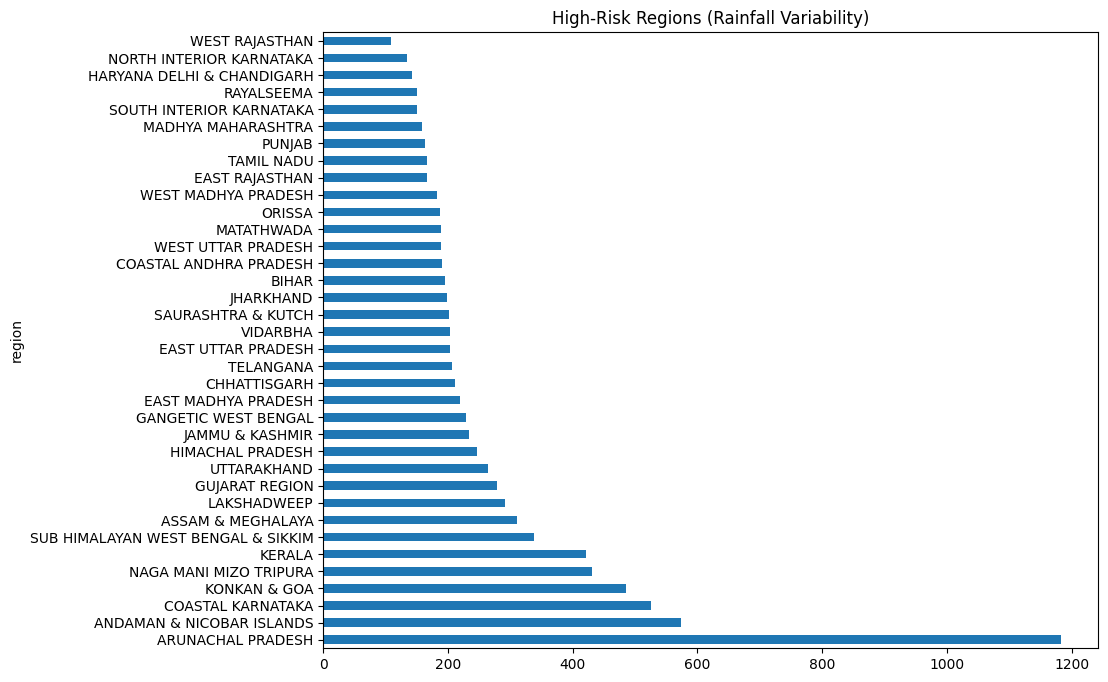

In [ ]:
risk.plot(kind='barh', figsize=(10,8))
plt.title("High-Risk Regions (Rainfall Variability)")
plt.show()

### Limitations

- External climate factors are not included
- Regional aggregation may mask local variations
- Rainfall is inherently unpredictable

### Final Conclusion

This project highlights the complexity of rainfall patterns in India.

While statistical and machine learning methods provide valuable insights, rainfall remains influenced by multiple interacting factors.

Understanding these patterns is crucial for climate resilience and informed decision-making.